# 03 — EDA and Weather Trend Analysis

This notebook explores the cleaned and feature-engineered weather dataset stored in DuckDB as `analytics.model_features`.

The goal is to understand city-level weather patterns, seasonal trends, tourism-relevant risks, and relationships between weather variables before modeling.

The main focus is on outdoor tourism planning, especially the May–June period.

## 1. Imports & Setup


In [24]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.db import run_query

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load Model-Ready Data


In [27]:
df = run_query("SELECT * FROM analytics.model_features").copy()

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time"].min(), "→", df["time"].max())
print("Cities:", df["city"].unique())

df.head()

Shape: (10925, 44)
Date range: 2020-01-08 00:00:00 → 2025-12-31 00:00:00
Cities: ['Baku' 'Gabala' 'Guba' 'Lankaran' 'Shaki']


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,...,wind_7d_avg,humidity_7d_avg,humidity_14d_avg,cloud_cover_7d_avg,rainy_days_7d,temperature_trend_1d,humidity_trend_1d,wind_trend_1d,precipitation_trend_1d,city_encoded
0,2020-01-08,10.1,0.0,14.2,84,51,7.3,29491.43,Baku,1,...,19.828571,87.428571,87.428571,69.714286,2.0,0.3,-2.0,-11.3,0.0,0
1,2020-01-09,9.2,0.4,30.2,88,97,4.2,9599.62,Baku,1,...,20.228571,86.571429,87.000000,72.714286,2.0,-0.9,4.0,16.0,0.4,0
2,2020-01-10,7.3,1.9,24.0,87,82,3.6,23398.28,Baku,1,...,19.828571,86.571429,87.111111,79.428571,2.0,-1.9,-1.0,-6.2,1.5,0
3,2020-01-11,6.1,2.1,16.3,88,91,4.2,0.00,Baku,1,...,19.814286,87.142857,87.100000,77.428571,2.0,-1.2,1.0,-7.7,0.2,0
4,2020-01-12,8.5,0.0,28.3,83,59,2.6,31925.68,Baku,1,...,18.900000,87.857143,87.181818,76.428571,3.0,2.4,-5.0,12.0,-2.1,0


## 3. Basic Dataset Overview


### 3.1 — structure

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10925 entries, 0 to 10924
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       10925 non-null  datetime64[ns]
 1   temperature_2m_max         10925 non-null  float64       
 2   precipitation_sum          10925 non-null  float64       
 3   wind_speed_10m_max         10925 non-null  float64       
 4   relative_humidity_2m_mean  10925 non-null  int64         
 5   cloud_cover_mean           10925 non-null  int64         
 6   apparent_temperature_max   10925 non-null  float64       
 7   sunshine_duration          10925 non-null  float64       
 8   city                       10925 non-null  object        
 9   month                      10925 non-null  int32         
 10  day_of_month               10925 non-null  int32         
 11  day_of_year                10925 non-null  int32         
 12  day_

### 3.2 — missing values and city counts

In [34]:
print("Missing values:")
display(df.isna().sum())

print("\nRows per city:")
display(df["city"].value_counts())

Missing values:


time                         0
temperature_2m_max           0
precipitation_sum            0
wind_speed_10m_max           0
relative_humidity_2m_mean    0
cloud_cover_mean             0
apparent_temperature_max     0
sunshine_duration            0
city                         0
month                        0
day_of_month                 0
day_of_year                  0
day_sin                      0
day_cos                      0
comfort_gap                  0
sunshine_ratio               0
rain_flag                    0
temperature_lag_1            0
temperature_lag_3            0
temperature_lag_7            0
precipitation_lag_1          0
precipitation_lag_3          0
precipitation_lag_7          0
wind_lag_1                   0
wind_lag_3                   0
humidity_lag_1               0
humidity_lag_3               0
temperature_3d_avg           0
temperature_7d_avg           0
temperature_14d_avg          0
precipitation_3d_sum         0
precipitation_7d_sum         0
precipit


Rows per city:


city
Baku        2185
Gabala      2185
Guba        2185
Lankaran    2185
Shaki       2185
Name: count, dtype: int64

## 4. City-Level Weather Summary


### 4.1 — target columns

In [38]:
target_cols = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
]

city_summary = (
    df.groupby("city")[target_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

city_summary

temperature_2m_max                               precipitation_sum  \
                       mean median        std   min   max              mean   
city                                                                          
Baku              19.601785   19.2   9.311038  -1.0  40.0          0.838490   
Gabala            22.012540   21.9  10.287400   0.1  42.4          1.011396   
Guba              16.398307   16.5  10.092811 -10.4  39.0          1.711762   
Lankaran          19.376751   19.1   8.075615  -0.1  36.5          2.658856   
Shaki             19.470618   19.5   9.454342  -1.4  38.5          2.061190   

                                       ... relative_humidity_2m_mean         \
         median       std  min    max  ...                      mean median   
city                                   ...                                    
Baku        0.0  2.738641  0.0   52.8  ...                 72.095195   73.0   
Gabala      0.0  3.288418  0.0   48.9  ...                 64.079634   65.0   
Guba        0.0  4.186680  0.0   93.2  ...                 69.256751   70.0   
Lankaran    0.0  7.412196  0.0  144.5  ...                 76.636156   78.0   
Shaki       0.0  5.865207  0.0   83.2  ...                 68.619680   70.0   

                            cloud_cover_mean                             
                std min max             mean median        std min  max  
city                                                                     
Baku      11.727996  32  97        47.993135   46.0  34.169884   0  100  
Gabala    16.953072  21  98        44.993593   43.0  31.532368   0  100  
Guba      16.094230  14  99        55.594966   58.0  33.413826   0  100  
Lankaran  11.031169  39  99        52.486957   52.0  35.196114   0  100  
Shaki     14.752211  22  99        47.880549   46.0  31.915983   0  100  

[5 rows x 25 columns]

### 4.2 — simpler tourism summary

In [41]:
tourism_summary = df.groupby("city").agg(
    avg_temp=("temperature_2m_max", "mean"),
    avg_precipitation=("precipitation_sum", "mean"),
    rainy_days=("precipitation_sum", lambda x: (x > 1).mean()),
    avg_wind=("wind_speed_10m_max", "mean"),
    avg_humidity=("relative_humidity_2m_mean", "mean"),
    avg_cloud_cover=("cloud_cover_mean", "mean"),
).reset_index()

tourism_summary["rainy_days_pct"] = tourism_summary["rainy_days"] * 100
tourism_summary = tourism_summary.drop(columns="rainy_days")

tourism_summary

,city,avg_temp,avg_precipitation,avg_wind,avg_humidity,avg_cloud_cover,rainy_days_pct
0,Baku,19.601785,0.838490,23.960778,72.095195,47.993135,16.338673
1,Gabala,22.012540,1.011396,15.256110,64.079634,44.993593,16.338673
2,Guba,16.398307,1.711762,13.268009,69.256751,55.594966,30.205950
3,Lankaran,19.376751,2.658856,14.123021,76.636156,52.486957,27.505721
4,Shaki,19.470618,2.061190,11.897437,68.619680,47.880549,23.890160


## 5. Seasonal Focus: May–June Tourism Window


### 5.1 — filter May–June

In [45]:
may_june_df = df[df["month"].isin([5, 6])].copy()

print("May–June shape:", may_june_df.shape)
print("Date range:", may_june_df["time"].min(), "→", may_june_df["time"].max())

may_june_df.head()

May–June shape: (1830, 44)
Date range: 2020-05-01 00:00:00 → 2025-06-30 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,...,wind_7d_avg,humidity_7d_avg,humidity_14d_avg,cloud_cover_7d_avg,rainy_days_7d,temperature_trend_1d,humidity_trend_1d,wind_trend_1d,precipitation_trend_1d,city_encoded
114,2020-05-01,19.5,0.0,20.2,78,24,18.5,46341.87,Baku,5,...,22.628571,74.857143,76.214286,58.857143,2.0,1.5,1.0,-2.8,0.0,0
115,2020-05-02,19.6,0.0,20.7,83,45,19.0,43993.52,Baku,5,...,22.900000,75.714286,76.785714,49.000000,1.0,0.1,5.0,0.5,0.0,0
116,2020-05-03,22.9,1.3,14.9,81,52,26.2,44030.64,Baku,5,...,23.128571,77.000000,76.714286,42.571429,0.0,3.3,-2.0,-5.8,1.3,0
117,2020-05-04,22.5,0.0,23.3,76,43,22.3,46191.04,Baku,5,...,22.728571,77.285714,76.642857,45.428571,1.0,-0.4,-5.0,8.4,-1.3,0
118,2020-05-05,25.8,0.0,21.6,62,85,24.7,33037.54,Baku,5,...,23.785714,77.000000,76.214286,47.857143,1.0,3.3,-14.0,-1.7,0.0,0


### 5.2 — May–June summary

In [48]:
may_june_summary = may_june_df.groupby("city").agg(
    avg_temp=("temperature_2m_max", "mean"),
    avg_precipitation=("precipitation_sum", "mean"),
    rainy_days_pct=("precipitation_sum", lambda x: (x > 1).mean() * 100),
    avg_wind=("wind_speed_10m_max", "mean"),
    avg_humidity=("relative_humidity_2m_mean", "mean"),
    avg_cloud_cover=("cloud_cover_mean", "mean"),
).reset_index()

may_june_summary.sort_values("avg_temp", ascending=False)

,city,avg_temp,avg_precipitation,rainy_days_pct,avg_wind,avg_humidity,avg_cloud_cover
1,Gabala,29.773224,1.453005,19.945355,17.189891,54.524590,41.994536
4,Shaki,26.322951,3.619126,34.972678,12.346995,65.336066,47.273224
0,Baku,25.825410,0.762842,14.754098,24.662568,65.912568,35.237705
3,Lankaran,24.743989,1.416940,20.765027,15.064481,74.508197,41.494536
2,Guba,23.315847,1.905191,31.967213,14.694262,63.030055,52.371585


## 6. Weather Trends by City


### 6.1 — temperature trend

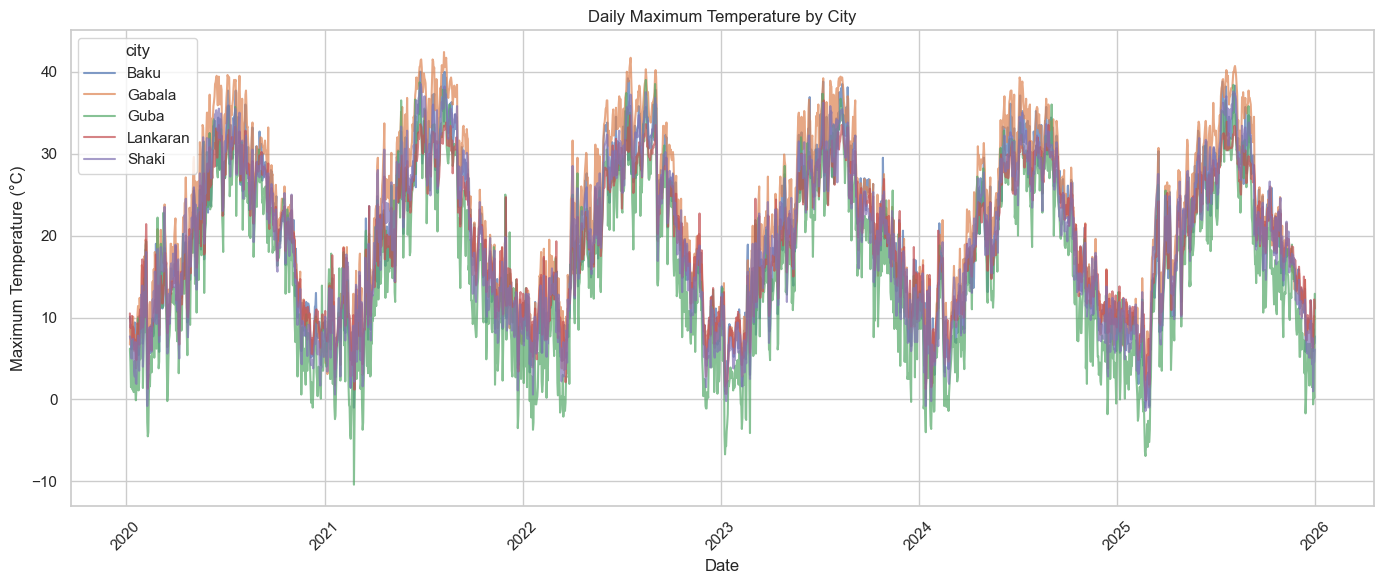

In [52]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="time",
    y="temperature_2m_max",
    hue="city",
    alpha=0.7,
)

plt.title("Daily Maximum Temperature by City")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 — monthly average temperature

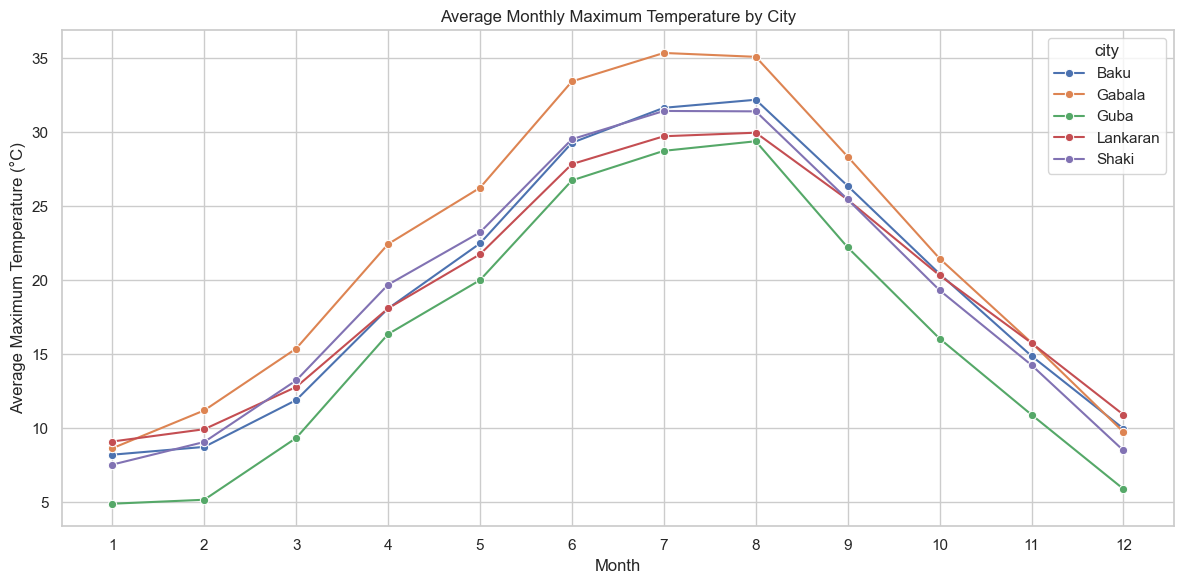

In [55]:
monthly_temp = (
    df.groupby(["city", "month"])["temperature_2m_max"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_temp,
    x="month",
    y="temperature_2m_max",
    hue="city",
    marker="o",
)

plt.title("Average Monthly Maximum Temperature by City")
plt.xlabel("Month")
plt.ylabel("Average Maximum Temperature (°C)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_temperature_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 — city comparison boxplots

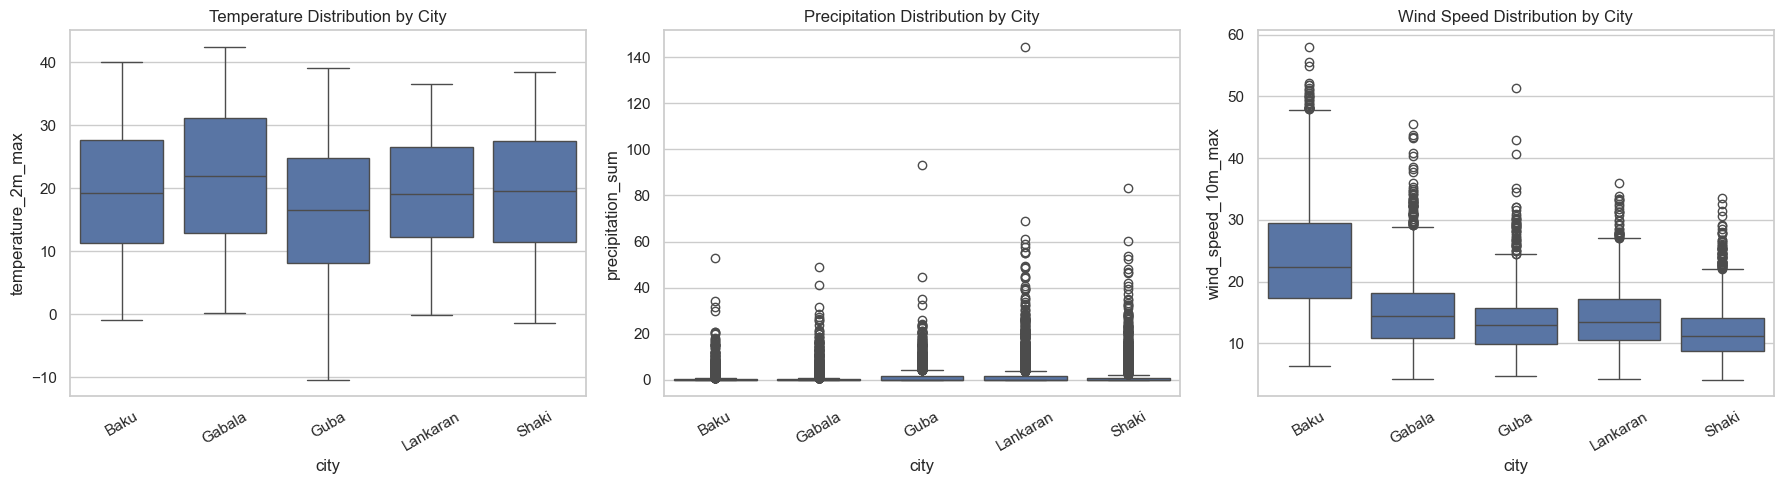

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="city", y="temperature_2m_max", ax=axes[0])
axes[0].set_title("Temperature Distribution by City")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="city", y="precipitation_sum", ax=axes[1])
axes[1].set_title("Precipitation Distribution by City")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="city", y="wind_speed_10m_max", ax=axes[2])
axes[2].set_title("Wind Speed Distribution by City")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "weather_distribution_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Analysis


### 7.1 — correlation matrix

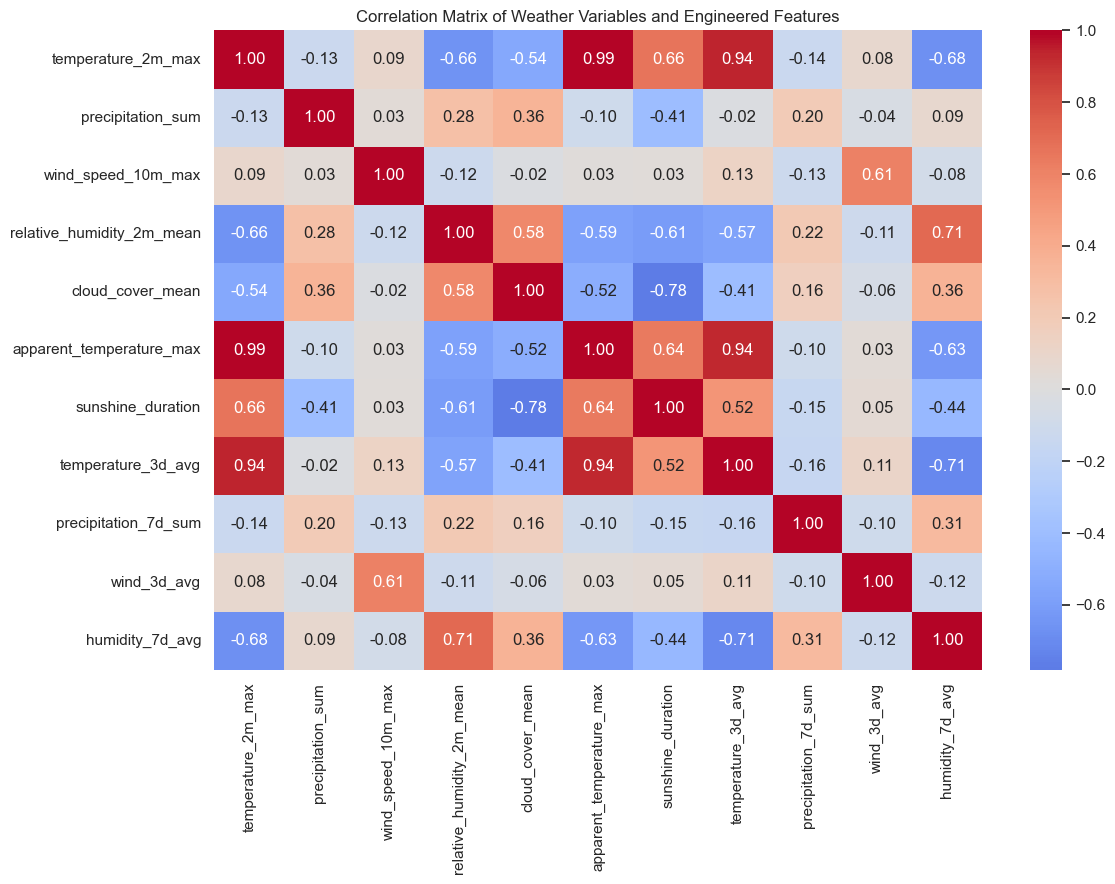

In [62]:
corr_cols = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "apparent_temperature_max",
    "sunshine_duration",
    "temperature_3d_avg",
    "precipitation_7d_sum",
    "wind_3d_avg",
    "humidity_7d_avg",
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Matrix of Weather Variables and Engineered Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weather_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 — top correlations with targets

In [65]:
target_corrs = corr_matrix[target_cols].drop(index=target_cols, errors="ignore")

for target in target_cols:
    print(f"\nTop correlations with {target}:")
    display(
        target_corrs[target]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )


Top correlations with temperature_2m_max:


apparent_temperature_max    0.989624
temperature_3d_avg          0.940348
humidity_7d_avg             0.675974
sunshine_duration           0.662102
precipitation_7d_sum        0.135272
Name: temperature_2m_max, dtype: float64


Top correlations with precipitation_sum:


sunshine_duration           0.407409
precipitation_7d_sum        0.195727
apparent_temperature_max    0.104268
humidity_7d_avg             0.086207
wind_3d_avg                 0.040809
Name: precipitation_sum, dtype: float64


Top correlations with wind_speed_10m_max:


wind_3d_avg             0.611633
temperature_3d_avg      0.127893
precipitation_7d_sum    0.125874
humidity_7d_avg         0.081579
sunshine_duration       0.028453
Name: wind_speed_10m_max, dtype: float64


Top correlations with relative_humidity_2m_mean:


humidity_7d_avg             0.714208
sunshine_duration           0.613459
apparent_temperature_max    0.585564
temperature_3d_avg          0.569345
precipitation_7d_sum        0.216943
Name: relative_humidity_2m_mean, dtype: float64


Top correlations with cloud_cover_mean:


sunshine_duration           0.780419
apparent_temperature_max    0.515321
temperature_3d_avg          0.407292
humidity_7d_avg             0.362429
precipitation_7d_sum        0.159367
Name: cloud_cover_mean, dtype: float64

## 8. Hypothesis Testing


### 8.1 — Temperature differs across cities
H0 (Null Hypothesis): Mean maximum temperature is the same across all cities.  
H1 (Alternative Hypothesis): At least one city has a different mean maximum temperature.

#### Normality

In [70]:
from scipy.stats import shapiro

for city, group in df.groupby("city"):
    stat, p = shapiro(group["temperature_2m_max"].dropna().sample(500))
    print(f"{city} normality p-value: {p:.4f}")

Baku normality p-value: 0.0000
Gabala normality p-value: 0.0000
Guba normality p-value: 0.0000
Lankaran normality p-value: 0.0000
Shaki normality p-value: 0.0000


#### Levene test

In [127]:
from scipy.stats import levene
temperature_groups = [
    group["temperature_2m_max"].dropna()
    for _, group in df.groupby("city")
]
levene_stat, levene_p = levene(*temperature_groups)
print(f"Levene p-value: {levene_p:.4f}")

Levene p-value: 0.0000


Shapiro-Wilk test shows p-values < 0.05 for all cities, indicating non-normal distributions.
Levene test also shows p < 0.05, meaning variances are not equal.
Because assumptions are not satisfied, we use the Kruskal-Wallis test, a non-parametric alternative that does not require normality.

In [130]:
from scipy.stats import kruskal

kruskal_stat, kruskal_p = kruskal(*temperature_groups)
print(f"Kruskal-Wallis statistic: {kruskal_stat:.4f}")
print(f"p-value: {kruskal_p:.6f}")

if kruskal_p < 0.05:
    print("Conclusion: Reject H0. Temperature differs significantly across cities.")
else:
    print("Conclusion: Fail to reject H0. No significant difference detected.")

Kruskal-Wallis statistic: 300.8543
p-value: 0.000000
Conclusion: Reject H0. Temperature differs significantly across cities.


#### Effect Size

In [44]:
n = len(df)
k = len(temperature_groups)

eta_squared = (kruskal_stat - k + 1) / (n - k)
print(f"Effect size: {eta_squared:.4f}")

Effect size: 0.0271


#### Post-Hoc Test

In [98]:
import scikit_posthocs as sp

dunn_temp = sp.posthoc_dunn(
    df,
    val_col="temperature_2m_max",
    group_col="city",
    p_adjust="bonferroni"
)

print("Post-hoc Dunn test for temperature differences across cities")
display(dunn_temp)

Post-hoc Dunn test for temperature differences across cities


,Baku,Gabala,Guba,Lankaran,Shaki
Baku,1.000000e+00,8.516061e-13,9.578767e-22,1.000000e+00,1.000000e+00
Gabala,8.516061e-13,1.000000e+00,6.842216e-66,3.091626e-14,9.459867e-14
Guba,9.578767e-22,6.842216e-66,1.000000e+00,5.929416e-20,1.541564e-20
Lankaran,1.000000e+00,3.091626e-14,5.929416e-20,1.000000e+00,1.000000e+00
Shaki,1.000000e+00,9.459867e-14,1.541564e-20,1.000000e+00,1.000000e+00


The Dunn test shows significant temperature differences between Gabala and Guba and all other cities (p < 0.05).
No significant differences are found between Baku, Lankaran, and Shaki.
This suggests that inland/mountain cities differ from coastal or lower-altitude cities in temperature patterns.

The Kruskal-Wallis test shows a statistically significant difference in temperature across cities (p < 0.05).
However, the effect size is small (η² ≈ 0.03), indicating that although differences exist, the magnitude of these differences is limited.
This suggests that while city location affects temperature, the variation may not be large enough to have a strong practical impact.

In [78]:
df['precipitation_sum'].max()

144.5

In [80]:
df['precipitation_sum'].min()

0.0

In [82]:
import pandas as pd
from scipy.stats import mannwhitneyu

# --- Step 1: Create suitable_day (your rule) ---
df["suitable_day"] = (
    (df["temperature_2m_max"].between(20, 28)) &
    (df["precipitation_sum"] < 5) &
    (df["wind_speed_10m_max"] < 25)
).astype(int)

# --- Step 2: Define a function to test variables ---
def test_feature(feature_name):
    group1 = df[df["suitable_day"] == 1][feature_name]
    group0 = df[df["suitable_day"] == 0][feature_name]
    
    stat, p = mannwhitneyu(group1, group0, alternative="two-sided")
    
    print(f"\nFeature: {feature_name}")
    print(f"Mean (Suitable): {group1.mean():.2f}")
    print(f"Mean (Not Suitable): {group0.mean():.2f}")
    print(f"p-value: {p:.5f}")
    
    if p < 0.05:
        print("✅ Significant difference → feature is important")
    else:
        print("❌ No significant difference → weak feature")

# --- Step 3: Run tests ---
test_feature("temperature_2m_max")
test_feature("precipitation_sum")
test_feature("wind_speed_10m_max")


Feature: temperature_2m_max
Mean (Suitable): 24.06
Mean (Not Suitable): 18.21
p-value: 0.00000
✅ Significant difference → feature is important

Feature: precipitation_sum
Mean (Suitable): 0.45
Mean (Not Suitable): 1.96
p-value: 0.00000
✅ Significant difference → feature is important

Feature: wind_speed_10m_max
Mean (Suitable): 14.08
Mean (Not Suitable): 16.10
p-value: 0.00000
✅ Significant difference → feature is important


In [86]:
from scipy.stats import mannwhitneyu

def test_new_feature(feature_name):
    group1 = df[df["suitable_day"] == 1][feature_name]
    group0 = df[df["suitable_day"] == 0][feature_name]
    
    stat, p = mannwhitneyu(group1, group0, alternative="two-sided")
    
    print(f"\nFeature: {feature_name}")
    print(f"Mean (Suitable): {group1.mean():.3f}")
    print(f"Mean (Not Suitable): {group0.mean():.3f}")
    print(f"p-value: {p:.5f}")
    
    if p < 0.05:
        print("✅ Useful feature (significant difference)")
    else:
        print("❌ Not useful feature")

In [88]:
df["rain_flag"] = (df["precipitation_sum"] > 2).astype(int)

test_new_feature("rain_flag")


Feature: rain_flag
Mean (Suitable): 0.080
Mean (Not Suitable): 0.194
p-value: 0.00000
✅ Useful feature (significant difference)


In [90]:
df["high_humidity_flag"] = (df["relative_humidity_2m_mean"] > 70).astype(int)

test_new_feature("high_humidity_flag")


Feature: high_humidity_flag
Mean (Suitable): 0.417
Mean (Not Suitable): 0.558
p-value: 0.00000
✅ Useful feature (significant difference)


In [92]:
df["comfort_gap"] = abs(
    df["apparent_temperature_max"] - df["temperature_2m_max"]
)

test_new_feature("comfort_gap")


Feature: comfort_gap
Mean (Suitable): 1.327
Mean (Not Suitable): 2.264
p-value: 0.00000
✅ Useful feature (significant difference)


In [94]:
df["high_sunshine"] = (df["sunshine_duration"] > 20000).astype(int)

test_new_feature("high_sunshine")


Feature: high_sunshine
Mean (Suitable): 0.940
Mean (Not Suitable): 0.759
p-value: 0.00000
✅ Useful feature (significant difference)


In [102]:
df["comfort_gap_lag_1"] = df.groupby("city")["comfort_gap"].shift(1)

In [104]:
test_new_feature("comfort_gap_lag_1")


Feature: comfort_gap_lag_1
Mean (Suitable): 1.355
Mean (Not Suitable): 2.255
p-value: nan
❌ Not useful feature


### Multi output Regressor

In [106]:
from scipy.stats import spearmanr

def test_feature_vs_targets(feature_name):
    targets = [
        "temperature_2m_max",
        "precipitation_sum",
        "wind_speed_10m_max",
        "relative_humidity_2m_mean",
        "cloud_cover_mean"
    ]
    
    print(f"\n🔍 Testing feature: {feature_name}")
    
    for target in targets:
        # drop NaNs (important for lag features)
        temp_df = df[[feature_name, target]].dropna()
        
        corr, p = spearmanr(temp_df[feature_name], temp_df[target])
        
        print(f"\nTarget: {target}")
        print(f"Correlation: {corr:.3f}")
        print(f"p-value: {p:.5f}")
        
        if p < 0.05:
            print("✅ Significant relationship")
        else:
            print("❌ No significant relationship")

In [109]:
test_feature_vs_targets('comfort_gap_lag_1')


🔍 Testing feature: comfort_gap_lag_1

Target: temperature_2m_max
Correlation: -0.397
p-value: 0.00000
✅ Significant relationship

Target: precipitation_sum
Correlation: -0.022
p-value: 0.02140
✅ Significant relationship

Target: wind_speed_10m_max
Correlation: -0.002
p-value: 0.84148
❌ No significant relationship

Target: relative_humidity_2m_mean
Correlation: 0.122
p-value: 0.00000
✅ Significant relationship

Target: cloud_cover_mean
Correlation: 0.062
p-value: 0.00000
✅ Significant relationship


In [96]:
from scipy.stats import chi2_contingency

def chi_square_test(feature_name):
    table = pd.crosstab(df[feature_name], df["suitable_day"])
    chi2, p, _, _ = chi2_contingency(table)
    
    print(f"\nFeature: {feature_name}")
    print(f"p-value: {p:.5f}")
    
    if p < 0.05:
        print("✅ Significant relationship")
    else:
        print("❌ No relationship")

In [98]:
chi_square_test('city')


Feature: city
p-value: 0.00000
✅ Significant relationship


In [100]:
chi_square_test('month')


Feature: month
p-value: 0.00000
✅ Significant relationship


### 8.2 - Hypothesis Test — Sunshine vs Cloud Cover

H0: No monotonic relationship between sunshine and cloud cover.  
H1: A relationship exists between sunshine and cloud cover.

In [51]:
from scipy.stats import shapiro

stat1, p1 = shapiro(df["sunshine_duration"].dropna().sample(500))
stat2, p2 = shapiro(df["cloud_cover_mean"].dropna().sample(500))

print(f"Sunshine normality p-value: {p1:.4f}")
print(f"Cloud cover normality p-value: {p2:.4f}")

Sunshine normality p-value: 0.0000
Cloud cover normality p-value: 0.0000


Normality tests indicate that variables are not normally distributed (p < 0.05).
Therefore, Spearman correlation is used instead of Pearson correlation.

In [57]:
from scipy.stats import spearmanr

stat, p = spearmanr(df["sunshine_duration"], df["cloud_cover_mean"])
print(f"\nSpearman correlation: {stat:.4f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("\nConclusion: Reject H0. Significant relationship exists.")
else:
    print("\nConclusion: No significant relationship.")


Spearman correlation: -0.7691
p-value: 0.000000

Conclusion: Reject H0. Significant relationship exists.


The correlation coefficient (ρ ≈ -0.77) indicates a strong negative relationship, meaning that higher cloud cover is associated with lower sunshine duration.

### 8.3 Hypothesis - Temperature as a Predictor of Relative Humidity?  
H0: There is no relationship between humidity and temperature.  
H1: There is a relationship between humidity and temperature.

**Assumption**: Since the data is not normally distributed, Spearman correlation is used as a non-parametric method.

In [116]:
from scipy.stats import spearmanr

stat, p = spearmanr(df["relative_humidity_2m_mean"], df["temperature_2m_max"])

print(f"\nCorrelation: {stat:.4f}")
print(f"p-value: {p:.6f}")



Correlation: -0.6457
p-value: 0.000000


The Spearman correlation shows a statistically significant and strong negative relationship between temperature and relative humidity (ρ ≈ -0.65, p < 0.05), indicating that higher temperatures are associated with lower humidity levels.
Since both variables are targets in the model, this relationship suggests that lagged and rolling temperature features (e.g., temperature_lag_1, temperature_3d_avg) can be useful predictors for humidity.

### 8.4 Hypothesis- Impact of Sunshine on Apparent Temperature
H0: There is no difference in apparent temperature between high and low sunshine days.  
H1: Apparent temperature differs between high and low sunshine days.

In [61]:
df["high_sunshine"] = (df["sunshine_duration"] > df["sunshine_duration"].median()).astype(int)

In [111]:
from scipy.stats import mannwhitneyu

high = df[df["high_sunshine"] == 1]["apparent_temperature_max"]
low = df[df["high_sunshine"] == 0]["apparent_temperature_max"]

stat, p = mannwhitneyu(high, low)
print(f"\nStatistic: {stat:.4f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("\nConclusion: Reject H0. Sunshine significantly affects perceived temperature.")
else:
    print("\nConclusion: No significant difference.")


Statistic: 26043805.5000
p-value: 0.000000

Conclusion: Reject H0. Sunshine significantly affects perceived temperature.


#### Effect size

In [70]:
from scipy.stats import mannwhitneyu
import numpy as np

stat, p = mannwhitneyu(high, low)

n1 = len(high)
n2 = len(low)

mean_U = n1 * n2 / 2
std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

z = (stat - mean_U) / std_U
r = z / np.sqrt(n1 + n2)

print(f"Effect size (r): {r:.4f}")

Effect size (r): 0.6374


In [68]:
print("Mean apparent temp (high sunshine):", high.mean())
print("Mean apparent temp (low sunshine):", low.mean())

Mean apparent temp (high sunshine): 25.739729779076136
Mean apparent temp (low sunshine): 11.177473530485578


The Mann–Whitney U test shows a statistically significant difference in apparent temperature between high and low sunshine days (p < 0.05), with a large effect size (r ≈ 0.64), indicating a strong impact. Days with higher sunshine have substantially higher apparent temperatures, suggesting that sunshine is an important factor in perceived weather comfort and a relevant feature for predicting apparent temperature in the model.


### 8.5 Statistical Feature Relevance Test

In [138]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np

targets = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean"
]

features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in targets
]

results = []

for target in targets:
    for feature in features:
        temp = df[[feature, target]].dropna()
        
        if temp[feature].nunique() > 1 and temp[target].nunique() > 1:
            rho, p = spearmanr(temp[feature], temp[target])
            
            results.append({
                "target": target,
                "feature": feature,
                "spearman_rho": rho,
                "p_value": p
            })

feature_test_results = pd.DataFrame(results)

# Multiple testing correction
feature_test_results["adjusted_p"] = multipletests(
    feature_test_results["p_value"],
    method="fdr_bh"
)[1]

feature_test_results["significant"] = feature_test_results["adjusted_p"] < 0.05

# Strength label
def strength_label(r):
    r = abs(r)
    if r < 0.1:
        return "negligible"
    elif r < 0.3:
        return "weak"
    elif r < 0.5:
        return "moderate"
    else:
        return "strong"

feature_test_results["effect_strength"] = feature_test_results["spearman_rho"].apply(strength_label)

feature_test_results.sort_values(
    ["target", "adjusted_p", "spearman_rho"],
    ascending=[True, True, False]
)

,target,feature,spearman_rho,p_value,adjusted_p,significant,effect_strength
63,cloud_cover_mean,humidity_lag_1,0.438382,0.000000e+00,0.000000e+00,True,moderate
67,cloud_cover_mean,humidity_7d_avg,0.432849,0.000000e+00,0.000000e+00,True,moderate
61,cloud_cover_mean,precipitation_lag_1,0.365781,0.000000e+00,0.000000e+00,True,moderate
65,cloud_cover_mean,precipitation_7d_sum,0.352842,0.000000e+00,0.000000e+00,True,moderate
60,cloud_cover_mean,temperature_lag_1,-0.442012,0.000000e+00,0.000000e+00,True,moderate
...,...,...,...,...,...,...,...
28,wind_speed_10m_max,apparent_temperature_max,0.119502,3.904769e-36,5.359486e-36,True,weak
29,wind_speed_10m_max,sunshine_duration,0.108027,8.446338e-30,1.137007e-29,True,weak
30,wind_speed_10m_max,month,-0.081706,1.078865e-17,1.398529e-17,True,negligible
33,wind_speed_10m_max,precipitation_lag_1,-0.039007,4.430002e-05,5.168336e-05,True,negligible


In [140]:
important_features = feature_test_results[
    (feature_test_results["significant"]) &
    (feature_test_results["effect_strength"].isin(["moderate", "strong"]))
].sort_values(["target", "effect_strength", "adjusted_p"])

important_features

,target,feature,spearman_rho,p_value,adjusted_p,significant,effect_strength
60,cloud_cover_mean,temperature_lag_1,-0.442012,0.000000e+00,0.000000e+00,True,moderate
61,cloud_cover_mean,precipitation_lag_1,0.365781,0.000000e+00,0.000000e+00,True,moderate
63,cloud_cover_mean,humidity_lag_1,0.438382,0.000000e+00,0.000000e+00,True,moderate
64,cloud_cover_mean,temperature_3d_avg,-0.465107,0.000000e+00,0.000000e+00,True,moderate
65,cloud_cover_mean,precipitation_7d_sum,0.352842,0.000000e+00,0.000000e+00,True,moderate
67,cloud_cover_mean,humidity_7d_avg,0.432849,0.000000e+00,0.000000e+00,True,moderate
56,cloud_cover_mean,apparent_temperature_max,-0.515917,0.000000e+00,0.000000e+00,True,strong
57,cloud_cover_mean,sunshine_duration,-0.769137,0.000000e+00,0.000000e+00,True,strong
69,cloud_cover_mean,high_sunshine,-0.637337,0.000000e+00,0.000000e+00,True,strong
19,precipitation_sum,precipitation_lag_1,0.406187,0.000000e+00,0.000000e+00,True,moderate


In [149]:
feature_test_results[
    (feature_test_results["significant"]) &
    (feature_test_results["effect_strength"].isin(["negligible","weak"]))
].sort_values(["target", "effect_strength", "adjusted_p"])

,target,feature,spearman_rho,p_value,adjusted_p,significant,effect_strength
66,cloud_cover_mean,wind_3d_avg,-0.078177,2.524499e-16,3.212999e-16,True,negligible
58,cloud_cover_mean,month,-0.061760,9.825441e-11,1.228180e-10,True,negligible
62,cloud_cover_mean,wind_lag_1,-0.052149,4.725596e-08,5.803364e-08,True,negligible
68,cloud_cover_mean,city_encoded,0.032589,6.460784e-04,7.294433e-04,True,negligible
59,cloud_cover_mean,day_of_month,-0.028093,3.275506e-03,3.639451e-03,True,negligible
26,precipitation_sum,city_encoded,0.087800,3.371012e-20,4.452280e-20,True,negligible
17,precipitation_sum,day_of_month,-0.024375,1.073147e-02,1.173754e-02,True,negligible
21,precipitation_sum,humidity_lag_1,0.244069,2.610156e-148,5.220312e-148,True,weak
14,precipitation_sum,apparent_temperature_max,-0.243097,4.138352e-147,8.046795e-147,True,weak
25,precipitation_sum,humidity_7d_avg,0.224737,1.837091e-125,3.475578e-125,True,weak


Multiple hypothesis tests are conducted to evaluate the relationship between candidate features and target variables using Spearman correlation.
To control for false positives due to multiple comparisons, the Benjamini–Hochberg correction is applied.

### 9.1 — simple comfort/risk flags

In [17]:
tourism_df = df.copy()

tourism_df["rain_risk"] = tourism_df["precipitation_sum"] > 1
tourism_df["strong_wind_risk"] = tourism_df["wind_speed_10m_max"] > 35
tourism_df["high_humidity_risk"] = tourism_df["relative_humidity_2m_mean"] > 80
tourism_df["cloudy_day"] = tourism_df["cloud_cover_mean"] > 70
tourism_df["comfortable_temp"] = tourism_df["temperature_2m_max"].between(18, 30)

tourism_risk_summary = tourism_df.groupby("city").agg(
    comfortable_temp_pct=("comfortable_temp", lambda x: x.mean() * 100),
    rain_risk_pct=("rain_risk", lambda x: x.mean() * 100),
    strong_wind_risk_pct=("strong_wind_risk", lambda x: x.mean() * 100),
    high_humidity_risk_pct=("high_humidity_risk", lambda x: x.mean() * 100),
    cloudy_day_pct=("cloudy_day", lambda x: x.mean() * 100),
).reset_index()

tourism_risk_summary

,city,comfortable_temp_pct,rain_risk_pct,strong_wind_risk_pct,high_humidity_risk_pct,cloudy_day_pct
0,Baku,36.649932,16.430853,10.862620,28.343222,32.998631
1,Gabala,33.409402,16.795984,0.547695,20.264719,25.832953
2,Guba,35.326335,30.625285,0.182565,29.301689,40.803286
3,Lankaran,44.135098,27.658603,0.045641,41.487905,37.608398
4,Shaki,38.886353,24.646280,0.000000,23.733455,29.803743


### 9.2 — May–June tourism suitability proxy

In [18]:
may_june_tourism = tourism_df[tourism_df["month"].isin([5, 6])].copy()

may_june_tourism_summary = may_june_tourism.groupby("city").agg(
    comfortable_temp_pct=("comfortable_temp", lambda x: x.mean() * 100),
    rain_risk_pct=("rain_risk", lambda x: x.mean() * 100),
    strong_wind_risk_pct=("strong_wind_risk", lambda x: x.mean() * 100),
    high_humidity_risk_pct=("high_humidity_risk", lambda x: x.mean() * 100),
    cloudy_day_pct=("cloudy_day", lambda x: x.mean() * 100),
).reset_index()

may_june_tourism_summary.sort_values("comfortable_temp_pct", ascending=False)

,city,comfortable_temp_pct,rain_risk_pct,strong_wind_risk_pct,high_humidity_risk_pct,cloudy_day_pct
3,Lankaran,83.606557,20.765027,0.000000,33.879781,21.311475
4,Shaki,72.404372,34.972678,0.000000,9.016393,23.497268
0,Baku,69.945355,14.754098,11.748634,4.371585,15.573770
2,Guba,68.032787,31.967213,0.000000,11.202186,30.054645
1,Gabala,44.808743,19.945355,0.546448,2.732240,17.759563


<Figure size 1200x600 with 0 Axes>

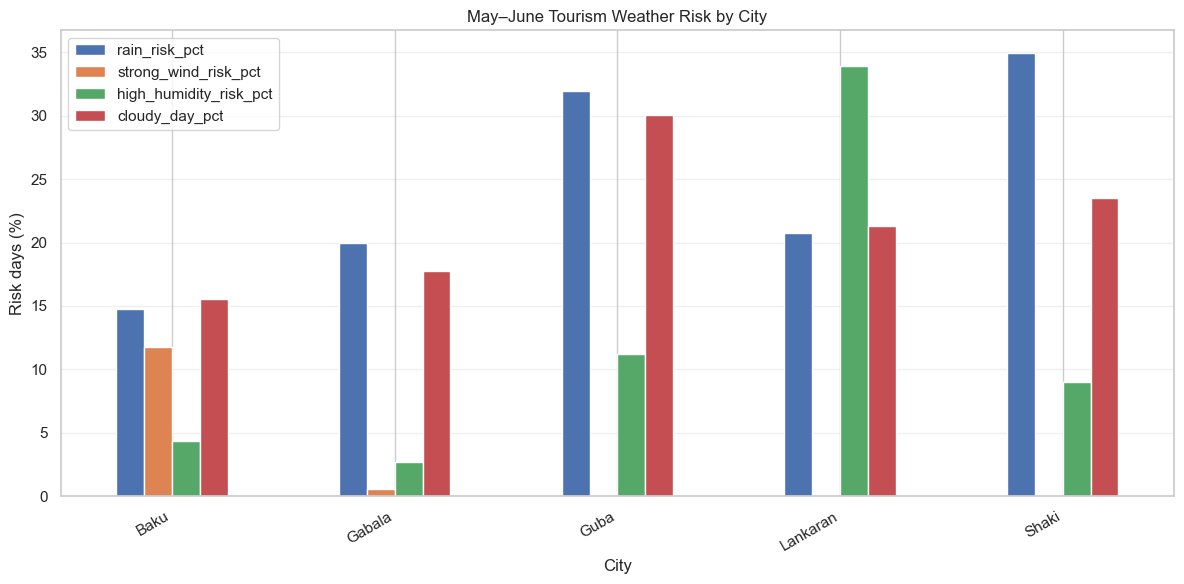

In [22]:
risk_cols = [
    "rain_risk_pct",
    "strong_wind_risk_pct",
    "high_humidity_risk_pct",
    "cloudy_day_pct",
]

risk_plot_df = may_june_tourism_summary.set_index("city")[risk_cols]

plt.figure(figsize=(12, 6))
risk_plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("May–June Tourism Weather Risk by City")
plt.xlabel("City")
plt.ylabel("Risk days (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "may_june_tourism_risk_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save Key Figures

Key figures were saved directly inside the plotting cells using `plt.savefig()`.

Saved outputs:

- `monthly_temperature_by_city.png`
- `weather_distribution_by_city.png`
- `weather_correlation_matrix.png`
- `may_june_tourism_risk_by_city.png`

## 11. EDA Summary

The EDA shows clear differences between cities in temperature, precipitation, wind, humidity, and cloud cover.

Key findings:

- Temperature patterns are strongly seasonal.
- Cities differ meaningfully in their average weather conditions.
- Precipitation and wind risks vary by location.
- May–June is a useful seasonal window for tourism planning.
- Correlation analysis confirms that engineered rolling features capture recent weather trends.
- Hypothesis tests support that weather conditions differ significantly across cities.

These insights support the modeling stage and the future activity suitability layer.